<a href="https://colab.research.google.com/github/walterCNeto/Modelagem/blob/main/PortOpt_ClassNotes_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MAD Optimizition**

Let's start by getting their monthly log-returns of over 900 stocks present in the Russell 2000 since Dec-2012

In [1]:
!pip install ipython-autotime

%load_ext autotime

import pandas as pd
import numpy as np
import scipy as sc
import random as rd
import seaborn as sns
import yfinance as yf  # noqa
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import norm
from IPython.display import display, Latex

from scipy.optimize import Bounds
from scipy.optimize import LinearConstraint

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.3 MB/s eta 0:00:00
time: 5.28 s (started: 2024-05-21 12:15:31 +00:00)


In [2]:
all_tickers = [
    'AAON','AAT','ABCB','ABG','ABM','ABR','ABUS','ACAD','ACCO','ACIC','ACIW','ACLS','ACNB','ACRE','ACTG','ADEA','ADTN','ADUS','AEHR','AEIS','AEL','AEO','AGEN','AGM','AGYS','AIN','AIR','AIT','AIV','AKR','ALCO','ALE','ALEX',
    'ALG','ALGT','ALKS','ALNT','ALX','AMBA','AMCX','AMKR','AMN','AMNB','AMRC','AMSF','AMSWA','AMWD','ANDE','ANF','ANGO','ANIK','ANIP','AORT','AOSL','APOG','ARAY','ARCB','ARI','ARL','AROC','AROW','ARR','ARTNA','ARWR',
    'ASGN','ASRT','ASTE','ASUR','ATEC','ATGE','ATI','ATLC','ATLO','ATNI','ATRC','ATRI','ATRO','ATSG','AVA','AVAV','AVD','AVNT','AVNW','AWR','AXL','AZZ','B','BANF','BANR','BBSI','BBW','BCBP','BCO','BCOV','BCPC','BCRX','BDC',
    'BDN','BECN','BELFB','BFH','BFS','BGC','BGFV','BGS','BH','BHB','BHE','BHLB','BIG','BJRI','BKD','BKE','BKH','BKU','BLKB','BLMN','BLX','BMI','BMRC','BOH','BOOM','BRKL','BRT','BSRR','BUSE','BXC','BXMT','BZH','CAC','CADE',
    'CAKE','CAL','CALM','CALX','CASH','CASS','CATO','CATY','CBAN','CBRL','CBT','CBU','CBZ','CCBG','CCNE','CCO','CCOI','CCRN','CDE','CDMO','CDP','CDXS','CDZI','CECO','CENT','CENTA','CENX','CERS','CEVA','CFFI','CFFN','CHCO',
    'CHEF','CHMG','CHUY','CIM','CIVB','CIX','CLAR','CLB','CLDT','CLDX','CLFD','CLMB','CLNE','CLW','CMC','CMCO','CMP','CMPR','CMRE','CMT','CMTL','CNK','CNO','CNOB','CNS','CNSL','CNTY','CNX','CNXN','CODI','COHU','COKE',
    'CORT','CPE','CPF','CPK','CPRX','CPSS','CRAI','CRD-A','CRK','CRMT','CRS','CRVL','CSGS','CSR','CSV','CTBI','CTLP','CTS','CUTR','CVBF','CVCO','CVCY','CVGI','CVGW','CVI','CVLG','CVLT','CVLY','CWCO','CWST','CWT','CXW',
    'CYH','CYTK','CZNC','DAKT','DAN','DBI','DCO','DCOM','DDD','DDS','DEI','DENN','DGICA','DGII','DHIL','DHT','DHX','DIN','DIOD','DJCO','DK','DLX','DMRC','DORM','DRH','DRQ','DSGR','DVAX','DX','DXLG','DXPE','DY','DZSI',
    'EAT','EBF','EBS','EBTC','ECPG','EFC','EFSC','EGAN','EGBN','EGHT','EGY','EHTH','EIG','ELA','ELME','ENS','ENSG','ENV','EPAC','EPC','EPM','EQC','ERII','ESCA','ESE','ESGR','ESSA','ETD','EVBN','EVC','EVI','EVRI','EXLS',
    'EXPO','EXTR','EYPT','FARO','FBIZ','FBNC','FBP','FC','FCBC','FCCO','FCEL','FCF','FCFS','FDP','FELE','FET','FF','FFBC','FFIC','FFIN','FIBK','FISI','FIX','FIZZ','FL','FLIC','FLR','FLWS','FMNB','FN','FNLC','FOLD','FOR',
    'FORM','FORR','FOSL','FRME','FRPH','FRST','FSBW','FSS','FUL','FULT','FWRD','GABC','GATX','GBX','GCBC','GCO','GDEN','GDOT','GEF','GEF-B','GEO','GERN','GES','GEVO','GFF','GHC','GIC','GIII','GLDD','GLNG','GLRE','GLT',
    'GNE','GNW','GOGL','GOOD','GPI','GPRE','GSBC','GT','GTN','GTY','GVA','HA','HAE','HAFC','HAIN','HALO','HAYN','HBCP','HBI','HBIO','HBNC','HCI','HCKT','HCSG','HDSN','HEAR','HEES','HELE','HFWA','HI','HIBB','HIFS','HL',
    'HLF','HLIT','HLX','HMN','HMST','HNI','HNRG','HOFT','HOPE','HOUS','HOV','HP','HPP','HSII','HSTM','HTBI','HTBK','HTH','HTLD','HTLF','HUBG','HURN','HVT','HWC','HWKN','HY','HZO','IBCP','IBOC','ICFI','IDCC','IDT','IESC',
    'III','IMAX','IMKTA','IMMR','INDB','INFN','INFU','INN','INOD','INSM','INVA','IOSP','IPAR','IPI','IRBT','IRWD','ITGR','ITIC','ITRI','IVAC','IVR','JACK','JAKK','JBLU','JBSS','JBT','JJSF','JOE','JOUT','KAI','KALU','KAMN',
    'KAR','KBH','KELYA','KFRC','KFS','KFY','KLIC','KMT','KOP','KOS','KRG','KRNY','KRO','KTOS','KVHI','KW','KWR','LANC','LBAI','LCII','LCNB','LCTX','LGF-A','LGND','LINC','LKFN','LMAT','LMNR','LNN','LNW','LPSN','LQDT',
    'LRN','LTC','LUMN','LUNA','LXFR','LXP','LXRX','LXU','LYTS','LZB','MAC','MACK','MATV','MATW','MATX','MBI','MBWM','MCBC','MCRI','MCS','MCY','MD','MDC','MDGL','MED','MEI','MFA','MG','MGEE','MGPI','MGRC','MHLD','MHO','MITK',
    'MLAB','MLI','MLKN','MLP','MLR','MMS','MMSI','MNKD','MNRO','MOD','MODG','MODV','MOFG','MOG-A','MOV','MPB','MPX','MRC','MRTN','MSEX','MSTR','MTDR','MTH','MTRN','MTSI','MTW','MTX','MUR','MVIS','MWA','MYE','MYGN','MYRG',
    'NAT','NATH','NATR','NBHC','NBN','NBR','NBTB','NC','NECB','NEO','NEOG','NEWT','NFBK','NG','NGVC','NHC','NHI','NJR','NKSH','NL','NNI','NOVT','NPK','NPO','NR','NRIM','NSIT','NSP','NSSC','NTCT','NTGR','NUS','NVAX','NVEC',
    'NVRI','NWBI','NWFL','NWLI','NWN','NWPX','NX','NXDT','NYMT','OCFC','OCN','ODC','OFG','OFIX','OFLX','OI','OII','OIS','OLP','OMCL','OMER','OMI','OPCH','ORA','ORRF','OSBC','OSIS','OSPN','OSUR','OTTR','OVLY','OXM','PACB',
    'PAR','PATK','PBF','PBH','PBI','PCH','PCRX','PCYO','PDCO','PDFS','PDM','PEB','PEBO','PETS','PFBC','PFC','PFMT','PFS','PGC','PIPR','PKBK','PKE','PKOH','PLAB','PLBC','PLCE','PLOW','PLPC','PLUS','PLX','PLXS','PMT','PNM',
    'PNRG','POR','POWI','POWL','PPBI','PRA','PRAA','PRDO','PRFT','PRG','PRGS','PRK','PRLB','PRMW','PRO','PRTA','PRTS','PSMT','PTEN','PTSI','PWOD','PZZA','QCRH','QLYS','QNST','QUAD','RBBN','RBCAA','RCKY','RDN','RDNT','RDUS',
    'RELL','REPX','RES','REX','RGCO','RGP','RGR','RHP','RICK','RIGL','RLGT','RLJ','RM','RMBS','ROCK','ROG','ROIC','RRGB','RUSHA','RUSHB','RWT','SAFE','SAFT','SAH','SANM','SASR','SATS','SAVA','SB','SBCF','SBGI','SBH',
    'SBRA','SBSI','SCHL','SCL','SCS','SCSC','SCVL','SEM','SENEA','SFL','SFNC','SGMO','SHBI','SHEN','SHO','SHOO','SHYF','SIG','SIGA','SIGI','SITC','SIX','SJW','SKT','SKY','SKYW','SLAB','SLCA','SLG','SLP','SM','SMBC',
    'SMCI','SMMF','SMP','SMTC','SNBR','SNEX','SNFCA','SP','SPNS','SPOK','SPSC','SPTN','SPWR','SPXC','SR','SRCE','SRDX','SRI','SSD','SSTK','STAA','STBA','STC','STGW','STKL','STNG','STRA','STRL','STRS','SUPN','SWBI','SWX',
    'SXC','SXI','SXT','SYBT','SYNA','TARO','TAST','TBBK','TBI','TBRG','TCBI','TCBK','TCI','TDS','TEX','TG','TGI','TGNA','THFF','THR','THRM','THS','TILE','TITN','TK','TLYS','TMP','TNC','TNK','TOWN','TPC','TRC','TREE','TRMK',
    'TRN','TRNO','TRNS','TROX','TRS','TRST','TSBK','TTEC','TTGT','TTI','TTMI','TTSH','TWI','TWO','UBSI','UCBI','UCTT','UEC','UFCS','UFPI','UFPT','UHT','UIS','ULH','UMBF','UMH','UNF','UNTY','UONE','UONEK','UPBD','URBN',
    'USLM','USNA','USPH','UTI','UTL','UTMD','UVSP','UVV','VALU','VATE','VCEL','VECO','VGR','VHI','VIAV','VICR','VLGEA','VNDA','VOXX','VPG','VRA','VRE','VRNT','VSEC','VSH','VTLE','VVI','WABC','WAFD','WASH','WD','WDFC',
    'WERN','WEYS','WGO','WINA','WIRE','WKC','WLDN','WLFC','WLY','WMK','WNC','WOR','WRLD','WSBC','WSBF','WSFS','WSR','WTBA','WTI','WTS','WWW','XOMA','YELP','YORW','ZD','ZEUS','ZUMZ','ZWS'
]

tickers = all_tickers[:-18:18]  # Reduce N

time: 5.55 ms (started: 2024-05-21 12:15:37 +00:00)


In [3]:
len(all_tickers[:-18:18])

50

time: 12.2 ms (started: 2024-05-21 12:15:37 +00:00)


In [4]:
# Get stock index prices
start_date = "2012-12-31"
end_date = "2023-12-31"
prices = pd.DataFrame(columns=tickers, dtype=float)
for i, ticker in enumerate(tickers):
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    prices[tickers[i]] = data["Close"].rename(tickers[i])

prices.ffill(inplace=True)  # Forward fill  nans (poor but simple approach to deal with missing values)
k = 21  # Non-overlapping log-returns for every 21-days
logrets = np.log1p(prices.iloc[::k, :].pct_change())
logrets = logrets.iloc[1:, :]  # Drop first row of log-returns since it contains only NaNs

time: 23 s (started: 2024-05-21 12:15:37 +00:00)


In [5]:
T = len(logrets)
N = len(logrets.columns)
print("Sample size: T = %i 21-d log-returns (between %s and %s), N = %i stocks" % (T, logrets.index[0].strftime("%d/%m/%Y"), logrets.index[-1].strftime("%d/%m/%Y"), N))

Sample size: T = 131 21-d log-returns (between 31/01/2013 and 05/12/2023), N = 50 stocks
time: 1.2 ms (started: 2024-05-21 12:16:00 +00:00)


(15705.0, 19696.0)

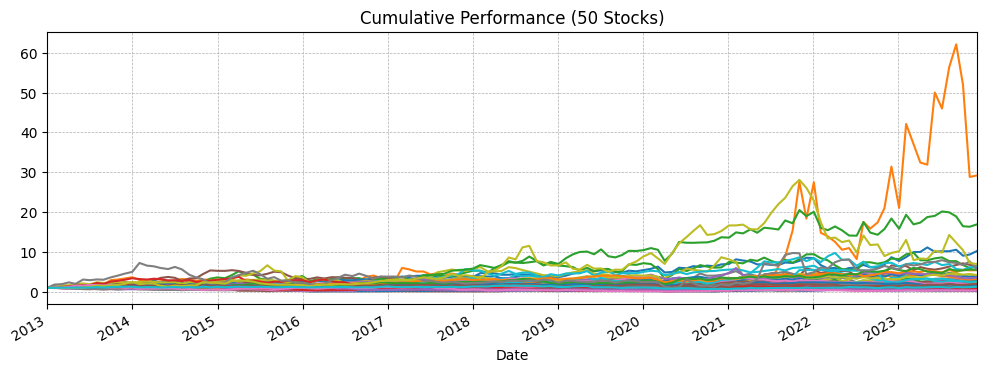

time: 1.52 s (started: 2024-05-21 12:16:00 +00:00)


In [6]:
cum_perf = np.exp(logrets.cumsum())
cum_perf.loc[prices.index[0]] = 1.0
cum_perf = cum_perf.sort_index()
ax = cum_perf.plot(title="Cumulative Performance (%i Stocks)" % N, figsize=(12,4), legend=False)
ax.xaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.yaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.set_xlim((cum_perf.index[0], cum_perf.index[-1]))

In [7]:
mus = logrets.mean().values.reshape(-1, 1)
covs = logrets.cov().values
rets = logrets  # Assuming logrets small enough such that r ~ ln(r + 1)

time: 19.2 ms (started: 2024-05-21 12:16:01 +00:00)


Also recall that:

- $R$ is [T x N]
- $\bar{R}$ or $\mu$ is [N x 1]
- $\Sigma$ is [N x N]
- $\omega$ is [N x 1]

In [8]:
Rp = lambda ws: (ws.T @ mus)[0]  # Portfolio's Expected Return
MADp = lambda ws: 1/T * np.sum(((rets - mus.T) @ ws).abs())  # Portfolio's MAD
Sp = lambda ws: np.sqrt(ws.T @ covs @ ws)

time: 910 µs (started: 2024-05-21 12:16:01 +00:00)


In [9]:
w0 = [1/N for _ in range(N)]  # Initial weights set to 1/N
bounds = [(0.0, 1.0) for _ in range(N)]
cons = {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
res_madp1 = sc.optimize.minimize(fun=MADp, x0=w0, method="slsqp", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12, options={"maxiter": 5000})
print(res_madp1)
ws_madp1 = res_madp1.x
Rp_madp1 = Rp(res_madp1.x)
Volp_madp1 = Sp(ws_madp1)
MADp_madp1 = res_madp1.fun

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.03021485657659905
       x: [ 1.422e-08  1.942e-18 ...  1.208e-17  2.410e-19]
     nit: 101
     jac: [ 3.155e-02  7.755e-02 ...  5.855e-02  3.347e-02]
    nfev: 5247
    njev: 101
time: 28 s (started: 2024-05-21 12:16:01 +00:00)


In [10]:
display(Latex(r"$\overline{R}_P = %.4f$" % Rp_madp1))  # MAD portfolio's expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_madp1))  # MAD portfolio's volatility
display(Latex(r"$MAD_P = %.4f$" % MADp_madp1))  # MAD portfolio's MAD

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

time: 10.4 ms (started: 2024-05-21 12:16:29 +00:00)


In [11]:
w0 = [1 for _ in range(N)]  # Initial weights set to 1 (to avoid NaN division during the optimization)
bounds = [(0.0, 1.0) for _ in range(N)]
cons = [
    {"type": "ineq", "fun": lambda ws: np.sum(ws) - 1},
    {"type": "ineq", "fun": lambda ws: -np.sum(ws) + 1}
]  # Weights must sum up to 1 (i.e., np.sum(ws) >= 1 and np.sum(ws) <= 1 since Cobyla only accepts inequalities as constraints)
res_madp2 = sc.optimize.minimize(fun=MADp, x0=w0, method="cobyla", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-18, options={"maxiter": 10000})
print(res_madp2)
ws_madp2 = res_madp2.x
Rp_madp2 = Rp(res_madp2.x)
Volp_madp2 = Sp(ws_madp2)
MADp_madp2 = res_madp2.fun

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 0.03044233643351308
       x: [ 8.846e-03 -1.845e-18 ... -1.561e-17  1.908e-02]
    nfev: 3213
   maxcv: 1.56089081265601e-17
time: 14.2 s (started: 2024-05-21 12:16:29 +00:00)


In [12]:
display(Latex(r"$\overline{R}_P = %.4f$" % Rp_madp2))  # MAD portfolio's expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_madp2))  # MAD portfolio's volatility
display(Latex(r"$MAD_P = %.4f$" % MADp_madp2))  # MAD portfolio's MAD

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

time: 11.2 ms (started: 2024-05-21 12:16:44 +00:00)


In [13]:
# from scipy.optimize import Bounds
# from scipy.optimize import LinearConstraint
# obs: requires ~9 min to run

w0 = [1/N for _ in range(N)]  # Initial weights set to 1/N
bounds = [(0.0, 1.0) for _ in range(N)]
cons = [
    LinearConstraint(np.ones([1, N]), 1.0, 1.0)
]
res_madp3 = sc.optimize.minimize(fun=MADp, x0=w0, method="trust-constr", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12, options={"maxiter": 5000})
print(res_madp3)
ws_madp3 = res_madp3.x
Rp_madp3 = Rp(res_madp3.x)
Volp_madp3 = Sp(ws_madp3)
MADp_madp3 = res_madp3.fun

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


           message: `xtol` termination condition is satisfied.
           success: True
            status: 2
               fun: 0.030623008840743454
                 x: [ 1.262e-02  2.043e-04 ...  3.685e-04  6.586e-03]
               nit: 1808
              nfev: 135303
              njev: 2653
              nhev: 0
          cg_niter: 5202
      cg_stop_cond: 2
              grad: [ 3.236e-02  8.028e-02 ...  5.522e-02  3.554e-02]
   lagrangian_grad: [ 1.393e-07  2.036e-09 ...  3.224e-09  1.761e-07]
            constr: [array([ 1.000e+00]), array([ 1.262e-02,  2.043e-04, ...,  3.685e-04,
                            6.586e-03])]
               jac: [array([[ 1.000e+00,  1.000e+00, ...,  1.000e+00,
                             1.000e+00]]), array([[ 1.000e+00,  0.000e+00, ...,  0.000e+00,
                             0.000e+00],
                           [ 0.000e+00,  1.000e+00, ...,  0.000e+00,
                             0.000e+00],
                           ...,
                 

In [14]:
display(Latex(r"$\overline{R}_P = %.4f$" % Rp_madp3))  # MAD portfolio's expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_madp3))  # MAD portfolio's volatility
display(Latex(r"$MAD_P = %.4f$" % MADp_madp3))  # MAD portfolio's MAD

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

time: 16.8 ms (started: 2024-05-21 12:25:37 +00:00)


In [15]:
np.argsort(res_madp3.x)

array([ 1,  2, 19, 48, 23, 13,  5, 46, 43, 32, 27,  7, 47,  3, 39, 22, 28,
       12, 26, 21, 20,  6, 29, 42, 10, 40, 38, 30, 14, 45, 31, 36, 37,  4,
       49,  9, 15, 35,  0, 24, 18, 44, 25, 33, 34,  8, 17, 41, 16, 11])

time: 7.74 ms (started: 2024-05-21 12:25:37 +00:00)


In [16]:
np.argsort(res_madp2.x)

array([48, 21, 20, 45, 43,  2, 39, 19, 23, 38, 10,  3, 32, 13, 22, 37, 28,
        1, 36,  4, 40,  7, 12, 42,  5, 29, 46,  6, 27, 47, 26, 31, 30, 14,
       18, 15,  0, 24, 49, 25,  9, 35, 33, 44, 34, 41, 17,  8, 16, 11])

time: 7.5 ms (started: 2024-05-21 12:25:37 +00:00)


In [17]:
np.argsort(res_madp1.x)

array([49, 12,  3, 39, 28, 38,  5, 22,  1, 26, 31,  4, 27, 29,  7, 43, 21,
        6, 37, 46, 14, 19, 47, 23, 13, 30, 20, 45,  2, 42, 10, 32, 48, 40,
       36,  9,  0, 35, 25, 18, 24, 15, 34, 44, 33,  8, 17, 16, 41, 11])

time: 7.04 ms (started: 2024-05-21 12:25:37 +00:00)


In [18]:
df_wgts = pd.DataFrame(index=tickers, columns=["slsqp", "cobyla", "trust-constr"], data=np.concatenate([res_madp1.x.reshape(-1, 1), res_madp2.x.reshape(-1, 1), res_madp3.x.reshape(-1, 1)], axis=1))
# df_wgts = pd.DataFrame(index=tickers, columns=["slsqp", "cobyla"], data=np.concatenate([res_madp1.x.reshape(-1, 1), res_madp2.x.reshape(-1, 1)], axis=1))

time: 3 ms (started: 2024-05-21 12:25:37 +00:00)


In [19]:
np.round(df_wgts.sort_values("cobyla", ascending=False).head(10), decimals=3)

,slsqp,cobyla,trust-constr
CPK,0.234,0.212,0.194
EVBN,0.140,0.187,0.148
CCBG,0.112,0.115,0.099
FDP,0.124,0.092,0.103
SIGI,0.173,0.083,0.121
ORA,0.033,0.069,0.055
TBRG,0.048,0.055,0.051
NWPX,0.071,0.044,0.055
PDCO,0.003,0.038,0.012
CHCO,0.000,0.035,0.009


time: 42.3 ms (started: 2024-05-21 12:25:37 +00:00)


In [20]:
ws_EF_MAD = [ws_madp1]
x_MAD_EF_MAD =[MADp_madp1]
x_MV_EF_MAD =[Volp_madp1]
y_EF_MAD =[Rp_madp1]

w0 = np.array([1/N for _ in range(N)])  # Initial weights set to 1/N
bounds = [(0.0, 1.0) for _ in range(N)]
tgt_mus = np.arange(0.006, 0.025, 0.001)
for i, tgt_mu in enumerate(tgt_mus):

    cons = [
        {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
        {"type": "ineq", "fun": lambda ws: Rp(ws) - tgt_mu}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
    ]
    res_madp = sc.optimize.minimize(fun=MADp, x0=w0, method="slsqp", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12, options={"maxiter": 5000})

    ws1_madp = res_madp.x
    Rp1_madp = Rp(res_madp.x)
    Volp1_madp = Sp(ws1_madp)
    MADp1_madp = res_madp.fun

    print("Optimization %i/%i (success: %s): %s (Rp=%.6f, MADp=%.6f, Volp=%.6f, ws_sum=%.2f)" % (i + 1, len(tgt_mus), res_madp.success, res_madp.message, Rp1_madp, MADp1_madp, Volp1_madp, np.sum(ws1_madp)))

    ws_EF_MAD.append(ws1_madp)
    x_MAD_EF_MAD.append(MADp1_madp)
    x_MV_EF_MAD.append(Volp1_madp)
    y_EF_MAD.append(Rp1_madp)

Optimization 1/20 (success: True): Optimization terminated successfully (Rp=0.006000, MADp=0.030238, Volp=0.044377, ws_sum=1.00)
Optimization 2/20 (success: True): Optimization terminated successfully (Rp=0.007000, MADp=0.030482, Volp=0.044488, ws_sum=1.00)
Optimization 3/20 (success: True): Optimization terminated successfully (Rp=0.008000, MADp=0.031122, Volp=0.045239, ws_sum=1.00)
Optimization 4/20 (success: True): Optimization terminated successfully (Rp=0.009000, MADp=0.031833, Volp=0.045955, ws_sum=1.00)
Optimization 5/20 (success: True): Optimization terminated successfully (Rp=0.010000, MADp=0.033043, Volp=0.047450, ws_sum=1.00)
Optimization 6/20 (success: True): Optimization terminated successfully (Rp=0.011000, MADp=0.034862, Volp=0.049906, ws_sum=1.00)
Optimization 7/20 (success: True): Optimization terminated successfully (Rp=0.012000, MADp=0.036771, Volp=0.050723, ws_sum=1.00)
Optimization 8/20 (success: True): Optimization terminated successfully (Rp=0.013000, MADp=0.0388

In [21]:
# Estimate the Minimum-Variance_Portfolio
cons = {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
res_mvp1 = sc.optimize.minimize(fun=Sp, x0=w0, method="slsqp", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12, options={"maxiter": 5000})
print(res_madp1)
ws_mvp1 = res_mvp1.x
Rp_mvp1 = Rp(res_mvp1.x)
Volp_mvp1 = res_mvp1.fun
MADp_mvp1 = MADp(ws_mvp1)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.03021485657659905
       x: [ 1.422e-08  1.942e-18 ...  1.208e-17  2.410e-19]
     nit: 101
     jac: [ 3.155e-02  7.755e-02 ...  5.855e-02  3.347e-02]
    nfev: 5247
    njev: 101
time: 119 ms (started: 2024-05-21 12:28:39 +00:00)


In [22]:
ws_EF_MV = [ws_mvp1]
x_MAD_EF_MV =[MADp_mvp1]
x_MV_EF_MV =[Volp_mvp1]
y_EF_MV =[Rp_mvp1]

w0 = np.array([1/N for _ in range(N)])  # Initial weights set to 1/N
bounds = [(0.0, 1.0) for _ in range(N)]
tgt_mus = np.arange(0.006, 0.025, 0.001)
for i, tgt_mu in enumerate(tgt_mus):

  # Perform a MV optimization for the current targed expected return tgt_mu
  cons = [
      {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
      {"type": "ineq", "fun": lambda ws: Rp(ws) - tgt_mu}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
  ]
  res_mvp = sc.optimize.minimize(fun=Sp, x0=w0, method="slsqp", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12, options={"maxiter": 5000})

  ws1_mvp = res_mvp.x
  Rp1_mvp = Rp(res_mvp.x)
  Volp1_mvp = res_mvp.fun
  MADp1_mvp = MADp(ws1_mvp)

  print("Optimization %i/%i (success: %s): %s (Rp=%.6f, MADp=%.6f, Volp=%.6f, ws_sum=%.2f)" % (i + 1, len(tgt_mus), res_mvp.success, res_mvp.message, Rp1_mvp, MADp1_mvp, Volp1_mvp, np.sum(ws1_mvp)))

  ws_EF_MV.append(ws1_mvp)
  x_MAD_EF_MV.append(MADp1_mvp)
  x_MV_EF_MV.append(Volp1_mvp)
  y_EF_MV.append(Rp1_mvp)

Optimization 1/20 (success: True): Optimization terminated successfully (Rp=0.006000, MADp=0.032092, Volp=0.041330, ws_sum=1.00)
Optimization 2/20 (success: True): Optimization terminated successfully (Rp=0.007000, MADp=0.032276, Volp=0.041610, ws_sum=1.00)
Optimization 3/20 (success: True): Optimization terminated successfully (Rp=0.008000, MADp=0.032699, Volp=0.042134, ws_sum=1.00)
Optimization 4/20 (success: True): Optimization terminated successfully (Rp=0.009000, MADp=0.033115, Volp=0.042993, ws_sum=1.00)
Optimization 5/20 (success: True): Optimization terminated successfully (Rp=0.010000, MADp=0.034099, Volp=0.044293, ws_sum=1.00)
Optimization 6/20 (success: True): Optimization terminated successfully (Rp=0.011000, MADp=0.035861, Volp=0.046024, ws_sum=1.00)
Optimization 7/20 (success: True): Optimization terminated successfully (Rp=0.012000, MADp=0.037693, Volp=0.048079, ws_sum=1.00)
Optimization 8/20 (success: True): Optimization terminated successfully (Rp=0.013000, MADp=0.0395

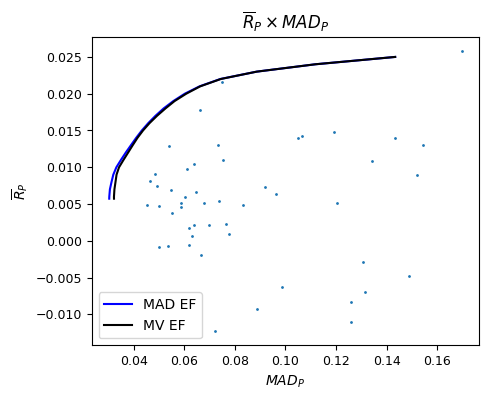

time: 899 ms (started: 2024-05-21 12:28:42 +00:00)


In [23]:
plt.figure(figsize=(5, 4))
plt.title(r"$\overline{R}_P \times MAD_P$")
plt.xlabel("$MAD_P$")
plt.ylabel("$\overline{R}_P$")

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.plot(x_MAD_EF_MAD, y_EF_MAD, color="blue", label=r"MAD EF")
plt.plot(x_MAD_EF_MV, y_EF_MAD, color="black", label=r"MV EF")
plt.legend()

w_instrs = np.eye(N, N)
y = [Rp(w) for w in w_instrs]
x = [MADp(w) for w in w_instrs]

plt.scatter(x, y, s=1)

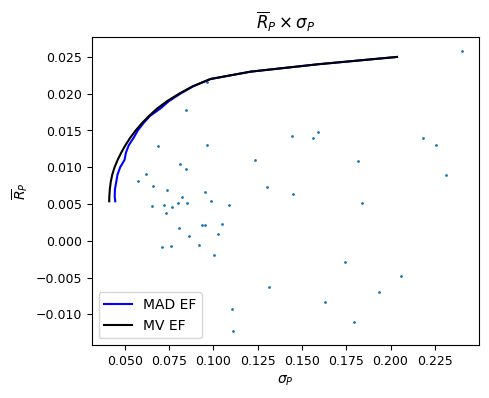

time: 606 ms (started: 2024-05-21 12:28:43 +00:00)


In [24]:
plt.figure(figsize=(5, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.ylabel("$\overline{R}_P$")

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.plot(x_MV_EF_MAD, y_EF_MV, color="blue", label=r"MAD EF")
plt.plot(x_MV_EF_MV, y_EF_MV, color="black", label=r"MV EF")
plt.legend()

w_instrs = np.eye(N, N)
y = [Rp(w) for w in w_instrs]
x = [Sp(w) for w in w_instrs]

plt.scatter(x, y, s=1)

Let's see an example of how we could modify the MAD optimization into an equivalent but simpler linear optimization problem.

We'll start with the original non-linear MAD optimization, subject to $\overline{R}_P$ $\geq$ 1.5%:

In [25]:
tgt_mu = 0.015
w0 = [1/N for _ in range(N)]  # Initial weights set to 1/N
bounds = [(0.0, 1.0) for _ in range(N)]
cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda ws: Rp(ws) - tgt_mu}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
]
res_madp_nonlin = sc.optimize.minimize(fun=MADp, x0=w0, method="slsqp", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12, options={"maxiter": 5000})
print(res_madp_nonlin)
ws_madp_nonlin = res_madp_nonlin.x
Rp_madp_nonlin = Rp(res_madp_nonlin.x)
Volp_madp_nonlin = Sp(ws_madp_nonlin)
MADp_madp_nonlin = res_madp_nonlin.fun

display(Latex(r"$\overline{R}_P = %.4f$" % Rp_madp_nonlin))  # MAD portfolio's expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_madp_nonlin))  # MAD portfolio's volatility
display(Latex(r"$MAD_P = %.4f$" % MADp_madp_nonlin))  # MAD portfolio's MAD

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.04311905316797039
       x: [ 2.752e-01  2.259e-02 ...  4.562e-18  1.483e-26]
     nit: 103
     jac: [ 4.869e-02  6.633e-02 ...  6.044e-02  3.331e-02]
    nfev: 5433
    njev: 103


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

time: 13.3 s (started: 2024-05-21 12:28:43 +00:00)


Then we'll solve the linear-equivalent optimization problem, also subject to $\overline{R}_P$ $\geq$ 1.5%:

In [26]:
alt_obj_fun_MADp = lambda xs: np.sum(xs[N:N + 2*T])  # Portfolio's MAD (linear formulation)

time: 627 µs (started: 2024-05-21 12:28:56 +00:00)


In [27]:
tgt_mu = 0.015
x0 = [0.0 for _ in range(N)] + [0 for _ in range(2*T)]  # Initial weights set to 1/N plus yt and zt, t = 1,...,N
bounds = [(0.0, 1.0) for _ in range(N)] + [(0.0, 1.0) for _ in range(2*T)]
cons = [
    {"type": "eq", "fun": lambda xs: np.sum(xs[0:N]) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda xs: Rp(xs[0:N]) - tgt_mu}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
    # {"type": "ineq", "fun": lambda xs: (xs[0:N].T @ mus - tgt_mu)[0]}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
]
for t in range(T):
    cons.append({"type": "eq", "fun": lambda xs: xs[N + t] - xs[N + T + t] - np.sum((rets.iloc[t].values.reshape(1, -1) - mus.T) @ xs[0:N].reshape(-1, 1))})  # yt - zt - Summation((rit - mus)*ws) = 0

res_madp_lin = sc.optimize.minimize(fun=alt_obj_fun_MADp, x0=x0, method="slsqp", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12, options={"maxiter": 5000})
print(res_madp_lin)
ws_madp_lin = res_madp_lin.x[0:N]
Rp_madp_lin = Rp(ws_madp_lin)
Volp_madp_lin = Sp(ws_madp_lin)
MADp_madp_lin = MADp(ws_madp_lin)

display(Latex(r"$\overline{R}_P = %.4f$" % Rp_madp_lin))  # MAD portfolio's expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_madp_lin))  # MAD portfolio's volatility
display(Latex(r"$MAD_P = %.4f$" % MADp_madp_lin))  # MAD portfolio's MAD

 message: Singular matrix C in LSQ subproblem
 success: False
  status: 6
     fun: 0.0
       x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
     nit: 1
     jac: [ 0.000e+00  0.000e+00 ...  1.000e+00  1.000e+00]
    nfev: 313
    njev: 1


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

time: 8.76 s (started: 2024-05-21 12:28:56 +00:00)


Notice that the minimize(SLSQP) method does not work in this case.

Let's try the linprog(HIGHS) method to see if we could reach a solution.

In [28]:
# c -> [N + 2T] 1-D array
c = np.array([0.0 for _ in range(N)] + [1.0 for _ in range(2*T)])

# linprog evalutes inequalities as A @ w <= b
# A_ub @ w >= b_ub => -A_ub @ w <= -b_ub
# A_ub -> [1, N + 2T] 2-D array
# b_ub -> [1, 1] scalar
A_ub = np.array([[-mus[i, 0] for i in range(N)] + [0.0 for _ in range(2*T)]])
b_ub = np.array([[-tgt_mu]])

# A_eq -> [T + 1, N + 2T] 2-D array
# Weights must sum up to one
A_eq = np.array([[1.0 for _ in range(N)] + [0.0 for _ in range(2*T)]])
b_eq = np.array([[1.0]])
for t in range(T):
    new_cons = np.array([[-rets.iloc[t, i] + mus[i, 0] for i in range(N)] + [1.0 if t == s else 0.0 for s in range(T)] + [-1.0 if t == s else 0.0 for s in range(T)]])
    A_eq = np.concatenate([A_eq, new_cons], axis=0)
    b_eq = np.concatenate([b_eq, np.array([[0.0]])], axis=0)

time: 169 ms (started: 2024-05-21 12:29:05 +00:00)


In [29]:
bounds_2 = [(0.0, 1.0) for _ in range(N)] + [(0.0, None) for _ in range(2*T)]
res_madp_lin_2 = sc.optimize.linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds_2, method='highs', callback=None, options={"maxiter": 5000, "disp": True}, integrality=0)
print(res_madp_lin_2)
ws_madp_lin_2 = res_madp_lin_2.x[0:N]
Rp_madp_lin_2 = Rp(ws_madp_lin_2)
Volp_madp_lin_2 = Sp(ws_madp_lin_2)
MADp_madp_lin_2 = MADp(ws_madp_lin_2)

display(Latex(r"$\overline{R}_P = %.4f$" % Rp_madp_lin_2))  # MAD portfolio's expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_madp_lin_2))  # MAD portfolio's volatility
display(Latex(r"$MAD_P = %.4f$" % MADp_madp_lin_2))  # MAD portfolio's MAD

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 5.648335527186536
              x: [ 2.724e-01  2.089e-02 ...  2.423e-02  0.000e+00]
            nit: 192
          lower:  residual: [ 2.724e-01  2.089e-02 ...  2.423e-02
                              0.000e+00]
                 marginals: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              2.000e+00]
          upper:  residual: [ 7.276e-01  9.791e-01 ...        inf
                                    inf]
                 marginals: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              0.000e+00]
          eqlin:  residual: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              0.000e+00]
                 marginals: [ 1.255e+00  1.000e+00 ... -1.000e+00
                              1.000e+00]
        ineqlin:  residual: [ 0.000e+00]
                 marginals: [-2.929e+02]
 mip_node_count: 0
 mip_dual_bo

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

time: 62.5 ms (started: 2024-05-21 12:29:05 +00:00)


Notice how much faster the linear MAD optimization based on linprog is when compared to the nonlinear implemention based on minimize(SLSQP).

For problems with many instruments and constraints, this convergence speed is often quite important.

# **TE Optimizition**

Let's start by uploading the prices of the ACWI, GBMI and NDX since Dec-2012

In [30]:
from google.colab import files
prices = files.upload()

time: 1h 11min 33s (started: 2024-05-21 12:29:05 +00:00)


In [31]:
import io
df_prices = pd.read_excel(io.BytesIO(prices.get(next(iter(prices)))))  # Be careful because the name "TE Example.xlsx" might change in subsequent runs
df_prices.set_index("Dates", inplace=True)
# df_prices

StopIteration: 

time: 168 ms (started: 2024-05-21 13:40:39 +00:00)


Now, let convert the daily prices in 5d log-returns

In [ ]:
df_prices.ffill(inplace=True)  # Just copy the previous price over missing values (not the best approach to deal with missing values)
k = 5  # Non-overlapping log-returns for every 5-days
df_logrets = np.log1p(df_prices.iloc[::k, :].pct_change().dropna())

In [ ]:
print("Sample size: %i %id log-returns between %s and %s" % (len(df_logrets), k, df_logrets.index[0].strftime("%d/%m/%Y"), df_logrets.index[-1].strftime("%d/%m/%Y")))

In [ ]:
df_cum_perf = np.exp(df_logrets.cumsum())
df_cum_perf.loc[df_prices.index[0]] = 1.0
df_cum_perf = df_cum_perf.sort_index()
ax = df_cum_perf.plot(title="Cumulative Performance", figsize=(12,4))
ax.xaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.yaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.set_xlim((df_cum_perf.index[0], df_cum_perf.index[-1]))
ax.legend(framealpha=1.0)

Finally, let's perform the backtest (BT), using the last 12 months before each rebalancing date, to estimate the means and covariances

In [ ]:
r = 51

TE = 0.01 / np.sqrt(r)  # Weekly TE (wrongly assuming that autocorrelation for all indexes is negligible)
TE2 = TE**2

T = len(df_logrets)
T_training = 1 * r  # ~51 weeks(5d) per year

start_i = T_training + 1
prev_i = start_i - 1
end_i = T

trns_costs = 0.0

names = df_logrets.columns.to_list()
N = len(names)

bmk_ws = pd.DataFrame(index=df_logrets.index[prev_i:end_i], columns=names, dtype=float)
bmk_logrets = pd.Series(index=df_logrets.index[prev_i:end_i], dtype=float)
bmk_vol = pd.Series(index=df_logrets.index[prev_i:end_i], dtype=float)

bmk_ws.iloc[0, :] = 0.0
bmk_logrets.iloc[0] = 0.0
bmk_vol.iloc[0] = 0.0

port_ws = pd.DataFrame(index=df_logrets.index[prev_i:end_i], columns=names, dtype=float)
port_logrets = pd.Series(index=df_logrets.index[prev_i:end_i], dtype=float)
port_vol = pd.Series(index=df_logrets.index[prev_i:end_i], dtype=float)
port_TEs = pd.DataFrame(index=df_logrets.index[prev_i:end_i], columns=["Ex-Ante", "Ex-Post"], dtype=float)

port_ws.iloc[0, :] = 0.0
port_logrets.iloc[0] = 0.0
port_vol.iloc[0] = 0.0
port_TEs.iloc[0, :] = 0.0

# Get the rebalancing dates
rebal_dates = port_ws.loc[port_ws.groupby(port_ws.index.to_period('M')).apply(lambda d: d.index.max())].index.to_list()

prev_date = df_logrets.index[prev_i]

j = 0
first_rebal = True
bmk_wgts = np.array([[0.60, 0.40, 0.00]]).T
for i in range(start_i, end_i):

    curr_date = df_logrets.index[i]

    covs = np.array(df_logrets.iloc[i-T_training-1:i-1, :].cov().values)

    # Compute the daily performance of each portfolio
    rets = np.expm1(df_logrets.loc[curr_date])

    bmk_ret = np.sum(bmk_ws.loc[prev_date] * rets)
    bmk_logrets.loc[curr_date] = np.log1p(bmk_ret)

    # Update the portfolio weights due to drift
    adj_bmk_ws = bmk_ws.loc[prev_date] * (1 + rets)
    if np.sum(adj_bmk_ws) > 0:
        bmk_ws.loc[curr_date, :] = adj_bmk_ws / np.sum(adj_bmk_ws)  # Normalize weights
    else:
        bmk_ws.loc[curr_date, :] = 0.0

    bmk_vol.loc[curr_date] = np.sqrt(bmk_ws.loc[curr_date, :].values @ covs @ bmk_ws.loc[curr_date, :].values.reshape(-1, 1) * r)[0]

    port_ret = np.sum(port_ws.loc[prev_date] * rets)
    port_logrets.loc[curr_date] = np.log1p(port_ret)
    # port_vols

    # Update the portfolio weights due to drift
    adj_port_ws = port_ws.loc[prev_date] * (1 + rets)
    if np.sum(adj_port_ws) > 0:
        port_ws.loc[curr_date, :] = adj_port_ws / np.sum(adj_port_ws)  # Normalize weights
    else:
        port_ws.loc[curr_date, :] = 0.0

    port_vol.loc[curr_date] = np.sqrt(port_ws.loc[curr_date, :].values @ covs @ port_ws.loc[curr_date, :].values.reshape(-1, 1) * r)[0]
    port_TEs.loc[curr_date, :] = [TE * np.sqrt(r), np.sqrt((port_ws-bmk_ws).loc[curr_date, :].values @ covs @ (port_ws-bmk_ws).loc[curr_date, :].values.reshape(-1, 1) * r)[0]]

    # Check if it is a rebalancing date
    if curr_date in rebal_dates:

        if first_rebal:
            i_first_alloc = i - start_i + 2
            first_rebal = False

        j += 1

        # Benchmark
        old_bmk_ws = bmk_ws.loc[curr_date, :].copy(deep=True)
        bmk_ws.loc[curr_date, :] = bmk_wgts.T
        delta_bmk_ws = np.abs(bmk_ws.loc[curr_date, :] - old_bmk_ws)
        rebal_bmk_trns_costs = np.sum(delta_bmk_ws * trns_costs)
        bmk_logrets.loc[curr_date] -= np.log1p(rebal_bmk_trns_costs)

        # Portfolio
        old_port_ws = port_ws.loc[curr_date, :].copy(deep=True)

        # Estimate expected returns and covariances (and, consequently, volatilities and correlations)
        mus = np.array(df_logrets.iloc[i-T_training-1:i-1, :].mean()).reshape(-1, 1)  # N x 1
        covs = np.array(df_logrets.iloc[i-T_training-1:i-1, :].cov().values)

        bmk_sig2 = (bmk_wgts.T @ covs @ bmk_wgts)[0]

        # Find optimal weights
        w0 = bmk_wgts.flatten()
        bounds = [(0.0, 1.0) for _ in range(N)]
        cons = [
            {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
            {"type": "ineq", "fun": lambda ws: -(ws-w0).T @ covs @ (ws-w0) + TE2}  # (ws-w0).T @ covs @ (ws-w0) >= TE**2 => -(ws-w0).T @ covs @ (ws-w0) + TE**2 <= 0
            # {"type": "ineq", "fun": lambda ws: -ws.T @ covs @ ws + bmk_sig2}   # ws.T @ covs @ ws >= sig**2 => -ws.T @ covs @ ws + sig**2 <= 0
        ]
        res = sc.optimize.minimize(fun=lambda ws: -ws.T @ mus, x0=w0, method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12)

        if not res.success:
            raise ValueError("TE optimization did not converged at rebalancing date '%s'" % curr_date.strftime("%d-%m-%Y"))
        else:
            w0 = w0.reshape(-1, 1)
            ws = res.x.reshape(-1, 1)
            # print("Optimization %i/%i (success: %s): %s (Rp=%.6f, Volp=%.6f, TEp=%.6f, ws_sum=%.2f)" % (j, len(rebal_dates), res.success, res.message, (ws.T @ mus * r)[0][0], np.sqrt(ws.T @ covs @ ws * r)[0][0], np.sqrt((ws-w0).T @ covs @ (ws-w0) * r)[0][0], np.sum(ws)))

        # Update weights and compute transaction costs
        port_ws.loc[curr_date, :] = res.x
        delta_port_ws = np.abs(port_ws.loc[curr_date, :] - old_port_ws)
        rebal_port_trns_costs = np.sum(delta_port_ws * trns_costs)
        port_logrets.loc[curr_date] -= np.log1p(rebal_port_trns_costs)

    prev_date = curr_date

Plot the backtest results:

In [ ]:
# Cumulative Performance
plt.figure(figsize=(7,4))
colors = ["green", "blue"]
plt.plot(np.exp(bmk_logrets.iloc[i_first_alloc:].cumsum()), label="Bench", color=colors[0], linewidth=0.5)
plt.plot(np.exp(port_logrets.iloc[i_first_alloc:].cumsum()), label="Port", color=colors[1], linewidth=0.5)
plt.title("Cumulative Returns")
plt.legend()

# Volatilities
plt.figure(figsize=(7,4))
colors = ["green", "blue"]
plt.plot(bmk_vol.iloc[i_first_alloc:], label="Bench", color=colors[0], linewidth=0.5)
plt.plot(port_vol.iloc[i_first_alloc:], label="Port", color=colors[1], linewidth=0.5)
plt.title("Annualized Volatilities")
plt.legend()

# Portfolio's TE
plt.figure(figsize=(7,4))
colors = ["green", "blue"]
plt.plot(port_TEs["Ex-Ante"].iloc[i_first_alloc:], label="Ex-Ante", color=colors[0], linewidth=0.5)
plt.plot(port_TEs["Ex-Post"].iloc[i_first_alloc:], label="Ex-Post", color=colors[1], linewidth=0.5)
plt.title("Portfolio's TE")
plt.legend()

In [ ]:
# Portfolio Allocation Weights
plt.figure(figsize=(7,4))
port_ws.plot.area(stacked=True)
plt.title("Portfolio Allocation Weights")
plt.legend(loc="lower left")
plt.xlim([port_ws.index[i_first_alloc], port_ws.index[-1]])
plt.ylim([0.0, 1.0])
plt.tight_layout()

# Benchmark Allocation Weights
plt.figure(figsize=(7,4))
bmk_ws.plot.area(stacked=True)
plt.title("Benchmark Allocation Weights")
plt.legend(loc="lower left")
plt.xlim([bmk_ws.index[i_first_alloc], bmk_ws.index[-1]])
plt.ylim([0.0, 1.0])
plt.tight_layout()

# Portfolio Allocation Weights (Equities vs Bonds)
port_ws2 = pd.concat([port_ws[["ACWI", "NDX"]].sum(axis=1), port_ws["GBMI"]], axis=1)
port_ws2.columns = ["Equities", "Bonds"]
plt.figure(figsize=(7,4))
port_ws2.plot.area(stacked=True)
plt.title("Portfolio Allocation Weights")
plt.legend(loc="lower left")
plt.xlim([port_ws2.index[i_first_alloc], port_ws2.index[-1]])
plt.ylim([0.0, 1.0])
plt.tight_layout()

# **Downside Risk Optimizition**

Let's start by obtaining the historical prices from several different commodities:

In [ ]:
from google.colab import files
prices = files.upload()

In [ ]:
import io
df_prices = pd.read_excel(io.BytesIO(prices.get(next(iter(prices)))))  # Be careful because the name "MDR Example.xlsx" might change in subsequent runs
df_prices.set_index("Dates", inplace=True)
# df_prices

Now, let convert the daily prices in 5d log-returns:

In [ ]:
df_prices.ffill(inplace=True)  # Just copy the previous price over missing values (not the best approach to deal with missing values)
k = 5  # Non-overlapping log-returns for every 5-days
L = 526
df_logrets = np.log1p(df_prices.iloc[-L::k, :].pct_change().dropna())

In [ ]:
df_logrets

In [ ]:
print("Sample size: %i %id log-returns between %s and %s" % (len(df_logrets), k, df_logrets.index[0].strftime("%d/%m/%Y"), df_logrets.index[-1].strftime("%d/%m/%Y")))

In [ ]:
df_cum_perf = np.exp(df_logrets.cumsum())
df_cum_perf.loc[df_prices.index[-L]] = 1.0
df_cum_perf = df_cum_perf.sort_index()
ax = df_cum_perf.plot(title="Cumulative Performance", figsize=(12,4))
ax.xaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.yaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.set_xlim((df_cum_perf.index[0], df_cum_perf.index[-1]))
# ax.legend(framealpha=1.0)
ax.get_legend().remove()

Then, let's estimate the minimum risk portfolio for both the MV and MDR models:

In [ ]:
mus = np.array(df_logrets.mean()).reshape(-1, 1)  # N x 1
covs = np.array(df_logrets.cov().values)
N = len(mus)

Rp = lambda ws: (ws.T @ mus)[0][0]  # Portfolio's Expected Return
Varp = lambda ws: ws.T @ covs @ ws  # Portfolio's Variance

def DR2p(ws):

    DR2 = 0.0   # Portfolio's DR^2
    for t in range(0, len(df_logrets)):
        DR2 += np.minimum(ws.reshape(1, -1) @ df_logrets.iloc[t].values.reshape(-1, 1), 0) ** 2
    DR2 = 1/(T-1) * DR2

    return DR2[0][0]

In [ ]:
# Find optimal MV weights
w0 = np.array([1.0/N for _ in range(N)])
bounds = [(0.0, 1.0) for _ in range(N)]
cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
]
res_mv = sc.optimize.minimize(fun=Varp, x0=w0, method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, options={"maxiter": 5000}, tol=1e-12)

In [ ]:
print(res_mv)

In [ ]:
# Find optimal MDR weights
w0 = np.array([1.0/N for _ in range(N)])
bounds = [(0.0, 1.0) for _ in range(N)]
cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
]
res_mdr = sc.optimize.minimize(fun=DR2p, x0=w0, method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, options={"maxiter": 5000}, tol=1e-12)

In [ ]:
print(res_mdr)

In [ ]:
alloc_wtgs = pd.DataFrame(index=df_logrets.columns, columns=["MV", "MDR"])
alloc_wtgs["MV"] = np.round(res_mv.x, decimals=3)
alloc_wtgs["MDR"] = np.round(res_mdr.x, decimals=3)

In [ ]:
alloc_wtgs.sort_values(by=['MDR'], ascending=False).head(10)

In [ ]:
top_mv_wtgs = alloc_wtgs["MV"].sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
ax_, txts = ax.pie(top_mv_wtgs.values)
plt.title("Minimum Variance Portfolio", fontsize = 14)
fig.legend(ax_, top_mv_wtgs.index.to_list(), loc="center right")
fig.show()

In [ ]:
top_mdr_wtgs = alloc_wtgs["MDR"].sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
ax_, txts = ax.pie(top_mdr_wtgs.values)
plt.title("Minimum Downside Risk Portfolio", fontsize = 14)
fig.legend(ax_, top_mdr_wtgs.index.to_list(), loc="center right")
fig.show()

# **CVaR Optimizition**


---

